# EDA — Retards IDFM (stop_visits)

Exploration des données de trafic accumulées dans Supabase pour préparer
le service `ml-traffic` (prédiction du retard moyen d'une ligne IDFM).

**Prérequis** : créer un fichier `.env` dans ce dossier à partir de `.env.example`.

**Sections**
1. Connexion & chargement
2. Couverture temporelle
3. Distribution des retards
4. Patterns temporels (heure, jour de semaine)
5. Lignes les plus instables
6. Corrélation retard / météo
7. Conclusions & features candidates

## 0. Imports & configuration

In [1]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Chargement .env (cherche dans le dossier du notebook)
env_path = Path('.env')
if not env_path.exists():
    raise FileNotFoundError(
        "Fichier .env introuvable. "
        "Copie .env.example en .env et remplis DATABASE_URL."
    )
load_dotenv(env_path)

DATABASE_URL = os.environ.get('DATABASE_URL')
if not DATABASE_URL:
    raise ValueError("DATABASE_URL manquante dans le .env")

print('✅ Configuration OK')

✅ Configuration OK


## 1. Connexion & chargement

In [8]:
!pip install "psycopg[binary]"

# Ensure the DATABASE_URL uses the correct SQLAlchemy dialect for psycopg3.
# The psycopg-binary package provides the 'psycopg' module, so the dialect should be 'postgresql+psycopg'.
# If it's currently 'postgresql+psycopg_binary', change it.
if DATABASE_URL.startswith('postgresql+psycopg_binary://'):
    DATABASE_URL = DATABASE_URL.replace('postgresql+psycopg_binary://', 'postgresql+psycopg://', 1)

engine = create_engine(DATABASE_URL)

sql_visits = text("""
    SELECT
        sv.id,
        sv.line_id,
        sv.transport_mode,
        sv.delay_seconds,
        sv.aimed_arrival,
        sv.expected_arrival,
        sv.arrival_status,
        sv.recorded_at,
        il.short_name  AS line_name,
        il.transport_mode AS line_mode
    FROM stop_visits sv
    LEFT JOIN idfm_lines il ON sv.line_id = il.line_id
    WHERE sv.delay_seconds IS NOT NULL
    ORDER BY sv.recorded_at
""")

with engine.connect() as conn:
    df = pd.read_sql(sql_visits, conn)

# Conversions
df['recorded_at'] = pd.to_datetime(df['recorded_at'], utc=True)
df['hour']        = df['recorded_at'].dt.hour
df['dow']         = df['recorded_at'].dt.dayofweek   # 0=lundi
df['date']        = df['recorded_at'].dt.date
df['delay_min']   = df['delay_seconds'] / 60
df['is_late']     = df['delay_seconds'] > 60
df['mode']        = df['line_mode'].fillna(df['transport_mode']).fillna('Inconnu')

print(f'Lignes chargées : {len(df):,}')
print(f'Période         : {df["recorded_at"].min().date()} → {df["recorded_at"].max().date()}')
print(f'Lignes IDFM     : {df["line_id"].nunique()}')
df.head(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.0/213.0 kB 3.6 MB/s eta 0:00:00
Lignes chargées : 30,472
Période         : 2026-04-24 → 2026-05-06
Lignes IDFM     : 31


,id,line_id,transport_mode,delay_seconds,aimed_arrival,expected_arrival,arrival_status,recorded_at,line_name,line_mode,hour,dow,date,delay_min,is_late,mode
0,2,STIF:Line::C01741:,unknown,0,NaT,NaT,onTime,2026-04-24 01:00:33.042000+00:00,U,rail,1,4,2026-04-24,0.0,False,rail
1,118,STIF:Line::C01741:,unknown,0,2026-04-24 16:01:50+00:00,2026-04-24 16:01:50+00:00,onTime,2026-04-24 01:00:33.067000+00:00,U,rail,1,4,2026-04-24,0.0,False,rail
2,105,STIF:Line::C01740:,unknown,0,2026-04-24 15:57:20+00:00,2026-04-24 15:57:20+00:00,onTime,2026-04-24 01:00:33.132000+00:00,L,rail,1,4,2026-04-24,0.0,False,rail


## 2. Couverture temporelle

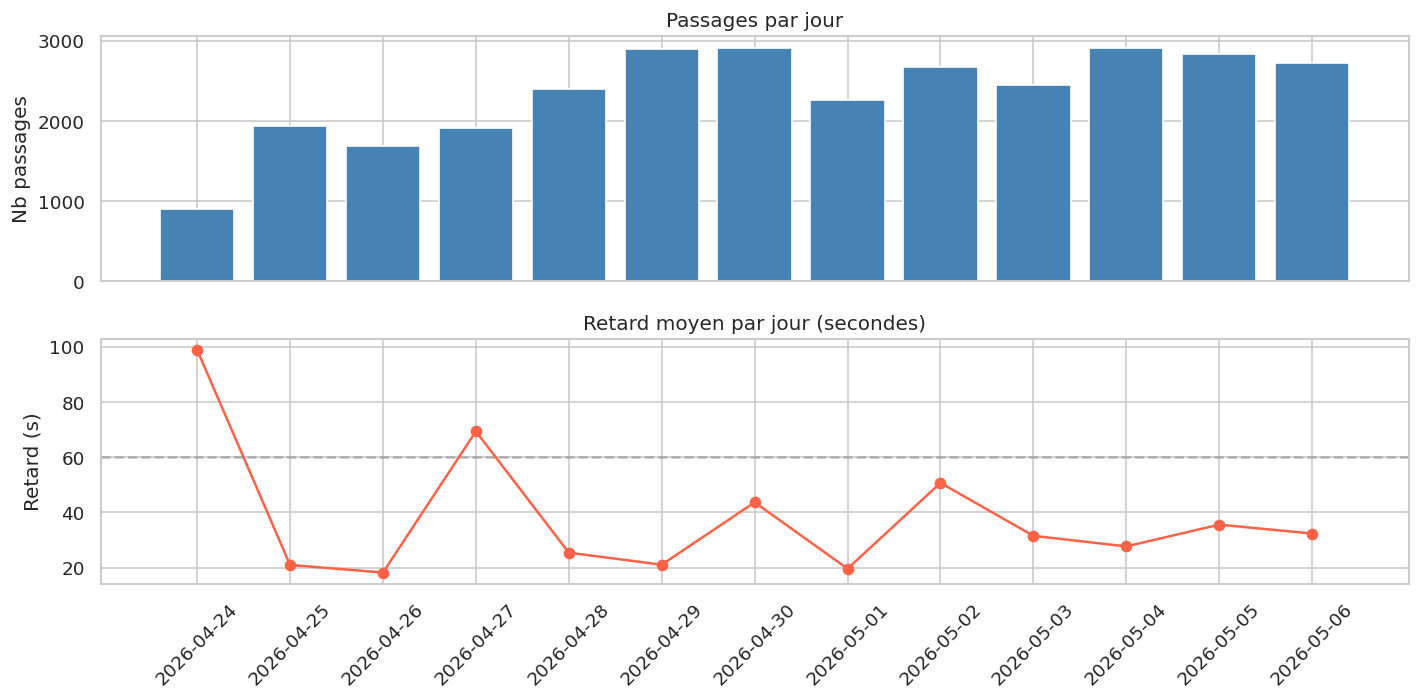

      date  passages  lignes_actives  retard_moyen_sec
2026-04-24       898              13         98.815145
2026-04-25      1939               8         20.989685
2026-04-26      1683               7         18.235294
2026-04-27      1914              18         69.337513
2026-04-28      2392              28         25.428094
2026-04-29      2894              21         21.077747
2026-04-30      2909              23         43.654520
2026-05-01      2264              15         19.632067
2026-05-02      2673              17         50.684624
2026-05-03      2448              15         31.515523
2026-05-04      2904              30         27.697314
2026-05-05      2838              31         35.575758
2026-05-06      2716              28         32.347202


In [9]:
# Volume par jour
daily = df.groupby('date').agg(
    passages=('id', 'count'),
    lignes_actives=('line_id', 'nunique'),
    retard_moyen_sec=('delay_seconds', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].bar(daily['date'].astype(str), daily['passages'], color='steelblue')
axes[0].set_title('Passages par jour')
axes[0].set_ylabel('Nb passages')

axes[1].plot(daily['date'].astype(str), daily['retard_moyen_sec'], marker='o', color='tomato')
axes[1].set_title('Retard moyen par jour (secondes)')
axes[1].set_ylabel('Retard (s)')
axes[1].axhline(60, color='gray', linestyle='--', alpha=0.5, label='60s')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_01_couverture_temporelle.png', bbox_inches='tight')
plt.show()
print(daily.to_string(index=False))

## 3. Distribution des retards

In [10]:
# Statistiques descriptives
print('=== Statistiques retard (secondes) ===')
print(df['delay_seconds'].describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(1))
print(f'\n% passages en retard (>60s) : {df["is_late"].mean()*100:.1f}%')
print(f'% passages à l\'heure (<0s)  : {(df["delay_seconds"] < 0).mean()*100:.1f}%')

=== Statistiques retard (secondes) ===
count    30472.0
mean        35.0
std        481.8
min      -7219.0
25%          0.0
50%          0.0
75%          0.0
90%         33.0
95%        110.0
99%        552.9
max      23590.0
Name: delay_seconds, dtype: float64

% passages en retard (>60s) : 7.2%
% passages à l'heure (<0s)  : 4.2%


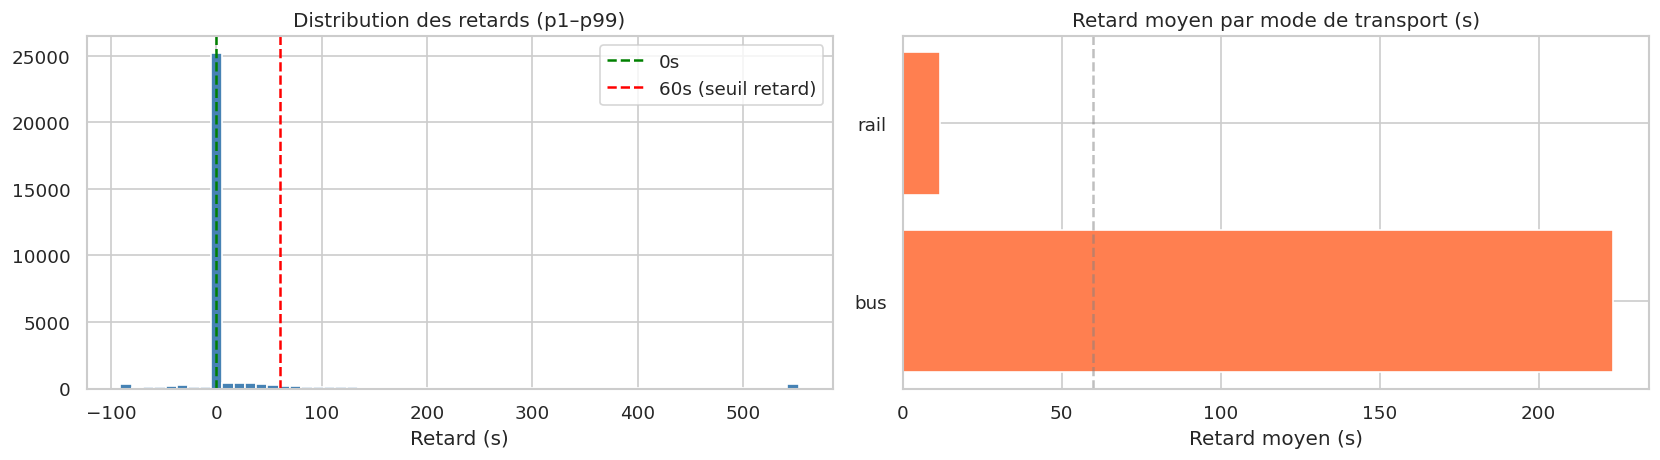

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution complète
clip_max = df['delay_seconds'].quantile(0.99)
clip_min = df['delay_seconds'].quantile(0.01)
data_clipped = df['delay_seconds'].clip(clip_min, clip_max)

axes[0].hist(data_clipped, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0,  color='green', linestyle='--', label='0s')
axes[0].axvline(60, color='red',   linestyle='--', label='60s (seuil retard)')
axes[0].set_title('Distribution des retards (p1–p99)')
axes[0].set_xlabel('Retard (s)')
axes[0].legend()

# Par mode de transport
mode_stats = df.groupby('mode')['delay_seconds'].mean().sort_values(ascending=False)
axes[1].barh(mode_stats.index, mode_stats.values, color='coral')
axes[1].axvline(60, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Retard moyen par mode de transport (s)')
axes[1].set_xlabel('Retard moyen (s)')

plt.tight_layout()
plt.savefig('fig_02_distribution_retards.png', bbox_inches='tight')
plt.show()

## 4. Patterns temporels

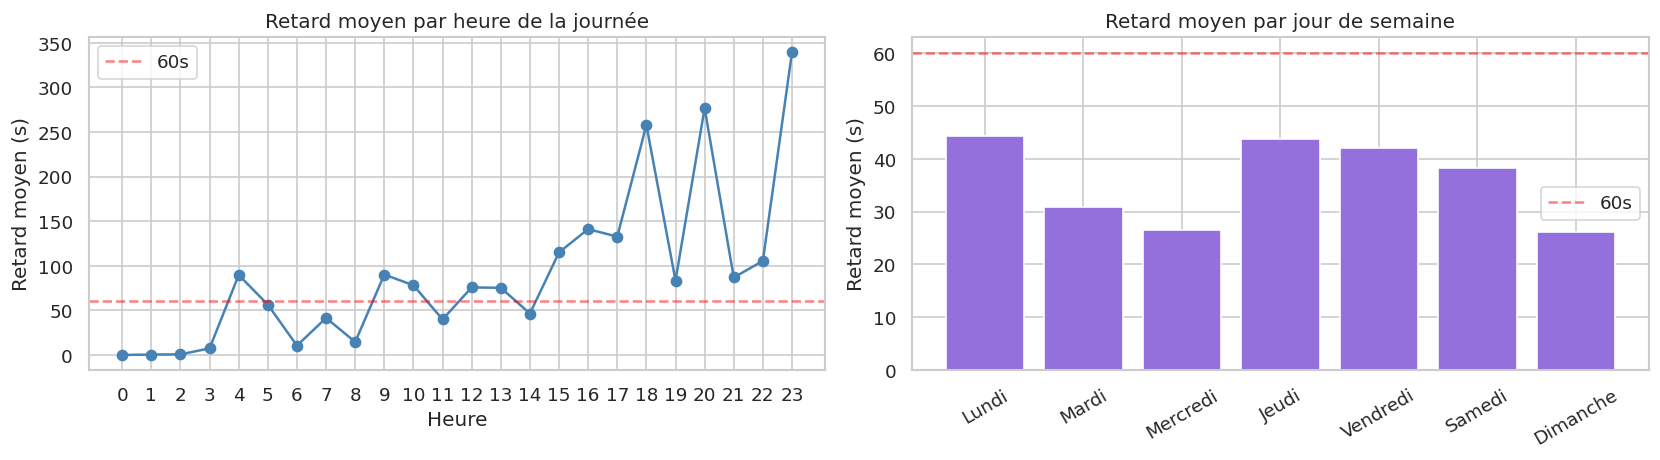

In [12]:
JOURS = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Retard moyen par heure
hour_stats = df.groupby('hour')['delay_seconds'].mean()
axes[0].plot(hour_stats.index, hour_stats.values, marker='o', color='steelblue')
axes[0].axhline(60, color='red', linestyle='--', alpha=0.5, label='60s')
axes[0].set_title('Retard moyen par heure de la journée')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Retard moyen (s)')
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# Retard moyen par jour de semaine
dow_stats = df.groupby('dow')['delay_seconds'].mean()
axes[1].bar(
    [JOURS[i] for i in dow_stats.index],
    dow_stats.values,
    color='mediumpurple'
)
axes[1].axhline(60, color='red', linestyle='--', alpha=0.5, label='60s')
axes[1].set_title('Retard moyen par jour de semaine')
axes[1].set_ylabel('Retard moyen (s)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_03_patterns_temporels.png', bbox_inches='tight')
plt.show()

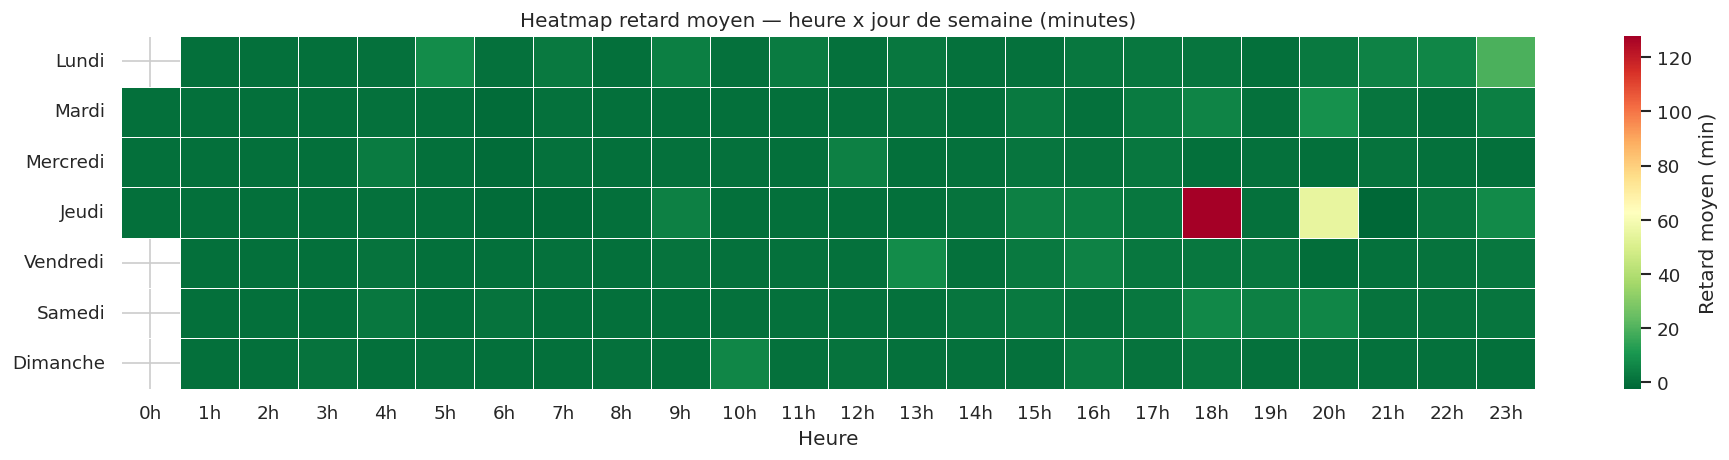

In [13]:
# Heatmap heure x jour de semaine
pivot = df.pivot_table(
    index='dow', columns='hour',
    values='delay_seconds', aggfunc='mean'
).reindex(index=range(7), columns=range(24))

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    pivot / 60,
    ax=ax,
    cmap='RdYlGn_r',
    linewidths=0.3,
    yticklabels=JOURS,
    xticklabels=[f'{h}h' for h in range(24)],
    cbar_kws={'label': 'Retard moyen (min)'},
)
ax.set_title('Heatmap retard moyen — heure x jour de semaine (minutes)')
ax.set_xlabel('Heure')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_04_heatmap_dow_hour.png', bbox_inches='tight')
plt.show()

## 5. Lignes les plus instables

In [14]:
line_stats = (
    df.groupby(['line_id', 'line_name', 'mode'])
    .agg(
        passages=('id', 'count'),
        retard_moyen_s=('delay_seconds', 'mean'),
        retard_std_s=('delay_seconds', 'std'),
        pct_late=('is_late', 'mean'),
    )
    .reset_index()
)
line_stats['pct_late'] = line_stats['pct_late'] * 100
line_stats = line_stats[line_stats['passages'] >= 20].sort_values('retard_moyen_s', ascending=False)

print('=== Top 15 lignes — retard moyen ===')
print(line_stats.head(15)[['line_name','mode','passages','retard_moyen_s','pct_late']].to_string(index=False))

=== Top 15 lignes — retard moyen ===
line_name mode  passages  retard_moyen_s  pct_late
     7812  bus        53      725.584906 22.641509
     Soir  bus        21      635.571429 23.809524
     5330  bus        21      538.476190 23.809524
     7822  bus       415      520.130120 18.313253
     7821  bus       593      325.767285 19.561551
     7811  bus        78      177.358974 35.897436
     7820  bus      1510      150.898013 16.026490
        L  bus       105      121.142857 21.904762
     N123  bus        52      107.076923 36.538462
      A14  bus        22       78.636364 31.818182
     5334  bus        21       78.523810 28.571429
     7825  bus        32       52.093750 31.250000
     5301  bus        69       48.159420 39.130435
     7810  bus        99       40.353535 34.343434
        U  bus        76       27.631579 14.473684


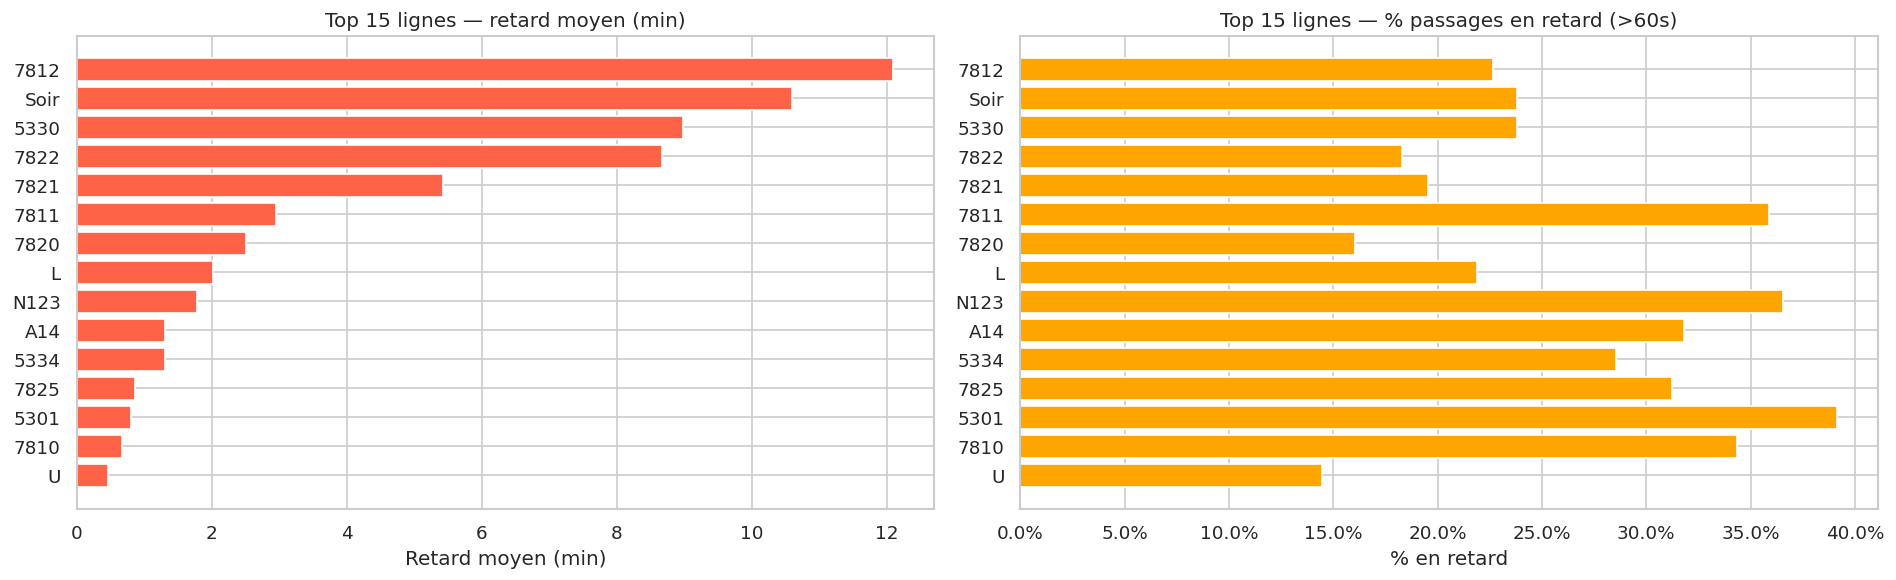

In [15]:
top15 = line_stats.head(15).copy()
top15['label'] = top15['line_name'].fillna(top15['line_id'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 retard moyen
axes[0].barh(
    top15['label'][::-1],
    top15['retard_moyen_s'][::-1] / 60,
    color='tomato'
)
axes[0].set_title('Top 15 lignes — retard moyen (min)')
axes[0].set_xlabel('Retard moyen (min)')

# % en retard
axes[1].barh(
    top15['label'][::-1],
    top15['pct_late'][::-1],
    color='orange'
)
axes[1].set_title('Top 15 lignes — % passages en retard (>60s)')
axes[1].set_xlabel('% en retard')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig('fig_05_top_lignes_instables.png', bbox_inches='tight')
plt.show()

## 6. Corrélation retard / météo

In [16]:
# Jointure avec weather_observations — on prend la mesure météo
# la plus proche dans le temps (fenêtre 1h)
sql_weather = text("""
    SELECT
        DATE_TRUNC('hour', observed_at) AS hour_slot,
        AVG(temperature_c)    AS temperature_c,
        AVG(precipitation_mm) AS precipitation_mm,
        AVG(wind_speed_ms)    AS wind_speed_ms,
        AVG(humidity_pct)     AS humidity_pct
    FROM weather_observations
    GROUP BY hour_slot
    ORDER BY hour_slot
""")

with engine.connect() as conn:
    df_weather = pd.read_sql(sql_weather, conn)

df_weather['hour_slot'] = pd.to_datetime(df_weather['hour_slot'], utc=True)

# Agrège stop_visits par heure
df['hour_slot'] = df['recorded_at'].dt.floor('h')
hourly_delay = df.groupby('hour_slot')['delay_seconds'].mean().reset_index()

# Merge
merged = hourly_delay.merge(df_weather, on='hour_slot', how='inner')
print(f'Heures avec données météo + trafic : {len(merged)}')
merged.head(3)

Heures avec données météo + trafic : 88


,hour_slot,delay_seconds,temperature_c,precipitation_mm,wind_speed_ms,humidity_pct
0,2026-04-28 09:00:00+00:00,0.000000,11.63,0.0,11.23,58.9
1,2026-04-29 11:00:00+00:00,11.616162,17.56,0.0,15.36,41.7
2,2026-04-29 13:00:00+00:00,13.750000,22.02,0.0,17.87,33.2


=== Corrélations avec le retard moyen horaire ===
temperature_c       0.205
precipitation_mm   -0.036
wind_speed_ms       0.164
humidity_pct       -0.198


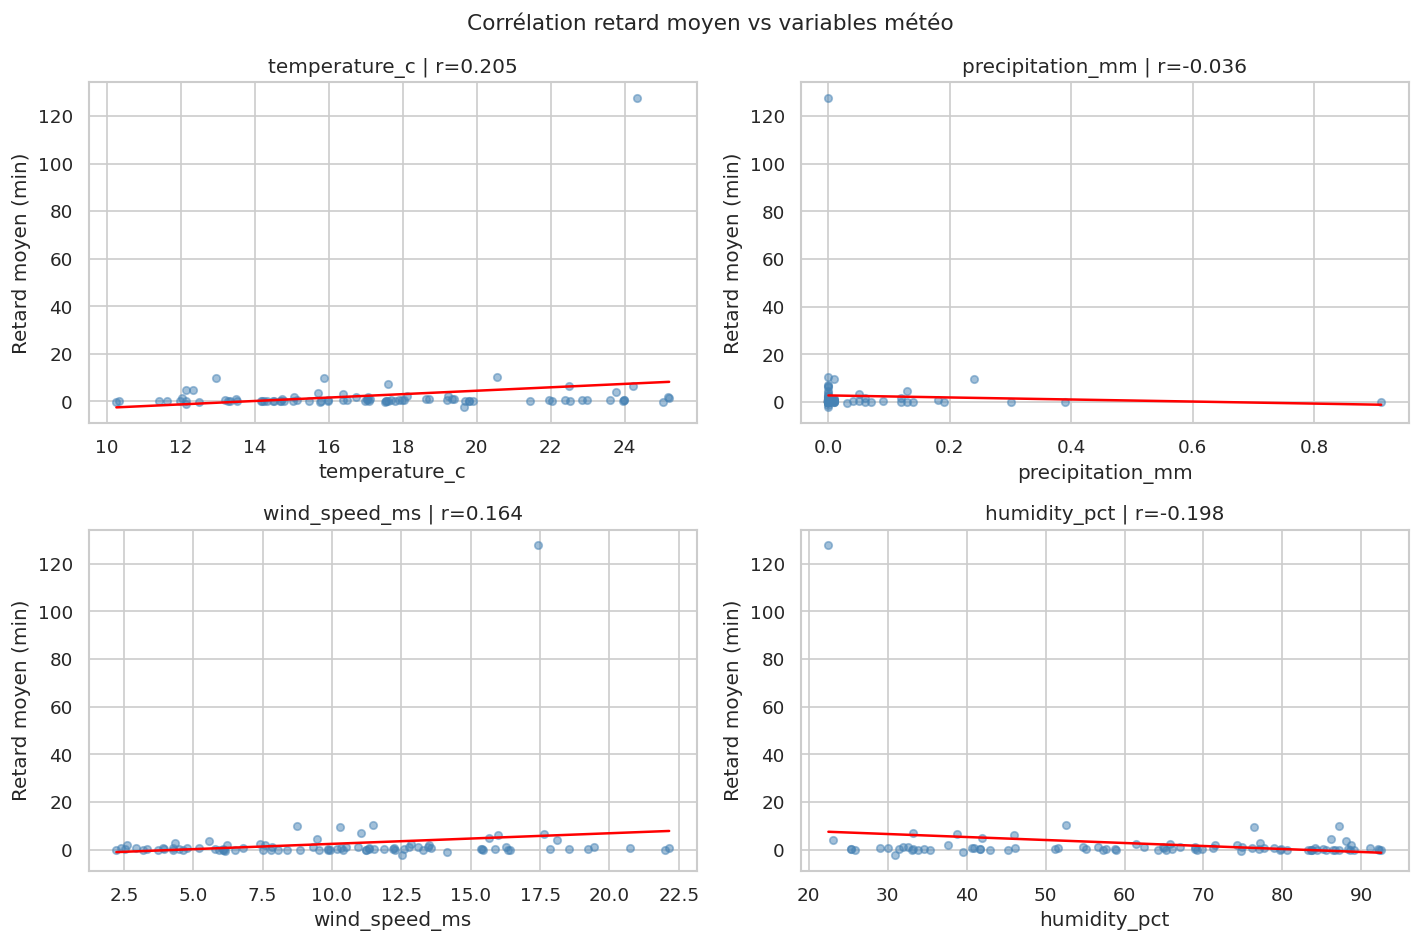

In [17]:
meteo_features = ['temperature_c', 'precipitation_mm', 'wind_speed_ms', 'humidity_pct']
correlations = merged[meteo_features + ['delay_seconds']].corr()['delay_seconds'].drop('delay_seconds')

print('=== Corrélations avec le retard moyen horaire ===')
print(correlations.round(3).to_string())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(meteo_features):
    axes[i].scatter(merged[feat], merged['delay_seconds'] / 60, alpha=0.5, s=20, color='steelblue')
    # Ligne de tendance
    z = np.polyfit(merged[feat].dropna(), merged.loc[merged[feat].notna(), 'delay_seconds'] / 60, 1)
    p = np.poly1d(z)
    x_range = np.linspace(merged[feat].min(), merged[feat].max(), 100)
    axes[i].plot(x_range, p(x_range), color='red', linewidth=1.5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Retard moyen (min)')
    axes[i].set_title(f'{feat} | r={correlations[feat]:.3f}')

plt.suptitle('Corrélation retard moyen vs variables météo', fontsize=13)
plt.tight_layout()
plt.savefig('fig_06_correlation_meteo.png', bbox_inches='tight')
plt.show()

## 7. Conclusions & features candidates

> *Cette cellule sera complétée après analyse des outputs ci-dessus.*

In [ ]:
# Résumé quantitatif final
print('=== RÉSUMÉ EDA ===')
print(f'Période analysée  : {df["recorded_at"].min().date()} → {df["recorded_at"].max().date()}')
print(f'Total passages    : {len(df):,}')
print(f'Lignes distinctes : {df["line_id"].nunique()}')
print(f'Retard médian     : {df["delay_seconds"].median():.0f}s')
print(f'Retard moyen      : {df["delay_seconds"].mean():.0f}s')
print(f'% en retard >60s  : {df["is_late"].mean()*100:.1f}%')
print()
print('=== MODES REPRÉSENTÉS ===')
print(df.groupby('mode')['id'].count().sort_values(ascending=False).to_string())
print()
print('=== FEATURES CANDIDATES POUR ML-TRAFFIC ===')
print('A remplir après analyse des graphiques.')